# Hash Table (Chaining) for Fast City Lookups

Uses a hash function to map city names to bucket indices, storing colliding
entries as linked lists within each bucket (separate chaining).

- Average case: O(1) insert / search / delete
- Worst case (all keys collide into one bucket): O(n)
- Resizes (rehashes) when load factor gets too high, to keep average case O(1)

In [1]:
class CityData:
    def __init__(self, name, latitude, longitude, population, distance=0.0):
        self.name = name
        self.latitude = latitude
        self.longitude = longitude
        self.population = population
        self.distance = distance

    def __repr__(self):
        return f"City({self.name}, pop={self.population}, dist={self.distance})"

In [2]:
class HashTable:
    """
    Hash table with separate chaining for collision handling.
    Keyed on city name. Each bucket is a Python list of (key, CityData) pairs.
    """

    def __init__(self, capacity=8, load_factor_threshold=0.75):
        self.capacity = capacity
        self.load_factor_threshold = load_factor_threshold
        self.size = 0
        self.buckets = [[] for _ in range(self.capacity)]

    def _hash(self, key):
        return hash(key) % self.capacity

    def _load_factor(self):
        return self.size / self.capacity

    def insert(self, city: CityData):
        if self._load_factor() >= self.load_factor_threshold:
            self._resize()

        idx = self._hash(city.name)
        bucket = self.buckets[idx]
        for i, (k, _) in enumerate(bucket):
            if k == city.name:
                bucket[i] = (city.name, city)  # update existing
                return
        bucket.append((city.name, city))
        self.size += 1

    def search(self, name):
        idx = self._hash(name)
        for k, city in self.buckets[idx]:
            if k == name:
                return city
        return None

    def delete(self, name):
        idx = self._hash(name)
        bucket = self.buckets[idx]
        for i, (k, _) in enumerate(bucket):
            if k == name:
                del bucket[i]
                self.size -= 1
                return True
        return False

    def _resize(self):
        old_buckets = self.buckets
        self.capacity *= 2
        self.buckets = [[] for _ in range(self.capacity)]
        self.size = 0
        for bucket in old_buckets:
            for _, city in bucket:
                self.insert(city)

    def bucket_lengths(self):
        """Useful for visualizing/analyzing collision distribution."""
        return [len(b) for b in self.buckets]

## Sanity Test

In [3]:
ht = HashTable(capacity=8)
names = ["Kathmandu", "Pokhara", "Biratnagar", "Lalitpur", "Bharatpur",
         "Butwal", "Dharan", "Hetauda", "Janakpur", "Nepalgunj"]

for i, name in enumerate(names):
    ht.insert(CityData(name, 0, 0, 100000 * (i + 1)))

print("Search Butwal:", ht.search("Butwal"))
print("Search NotACity:", ht.search("NotACity"))
print("Size:", ht.size, "| Capacity:", ht.capacity, "| Load factor:", round(ht._load_factor(), 2))

ht.delete("Pokhara")
print("After delete, search Pokhara:", ht.search("Pokhara"))
print("Bucket lengths:", ht.bucket_lengths())

Search Butwal: City(Butwal, pop=600000, dist=0.0)
Search NotACity: None
Size: 10 | Capacity: 16 | Load factor: 0.62
After delete, search Pokhara: None
Bucket lengths: [0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 1, 0, 0, 2, 0, 0]


## Visualizing Bucket Distribution (Collisions)

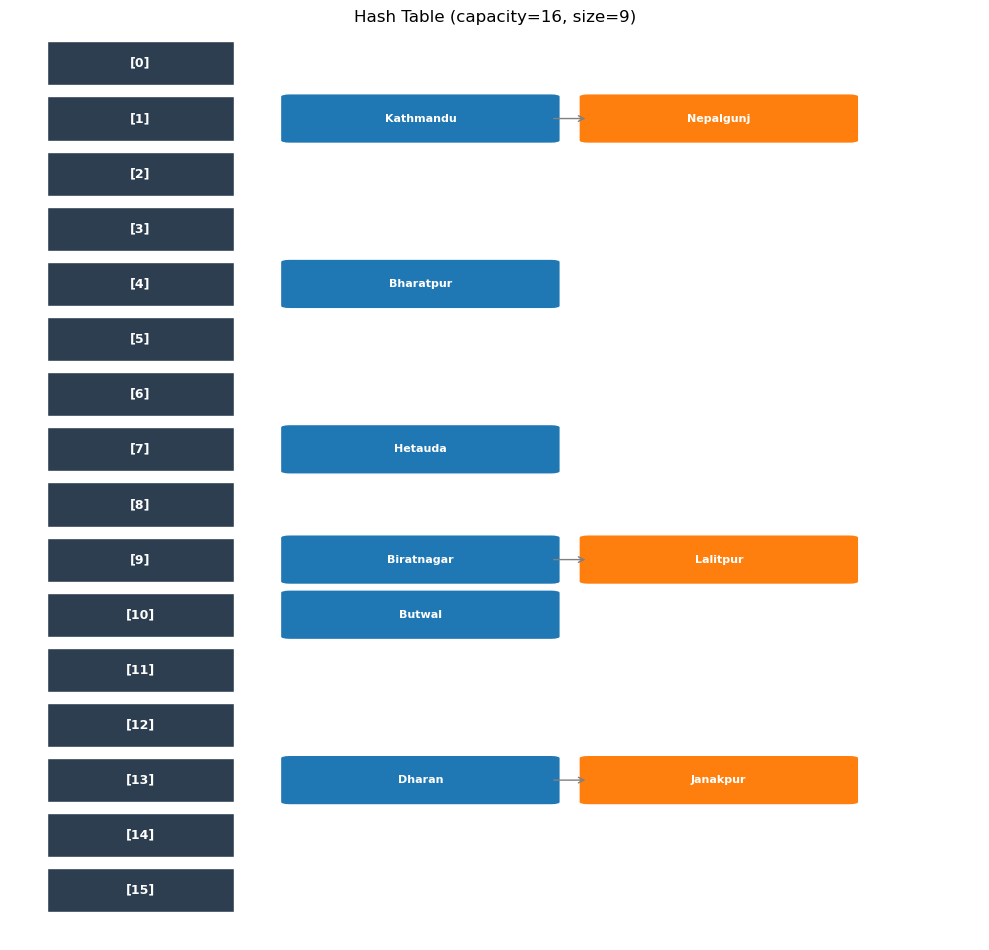

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_hash_table(ht, title="Hash Table Bucket Distribution"):
    fig, ax = plt.subplots(figsize=(10, max(4, ht.capacity * 0.6)))

    colors = plt.cm.tab10.colors
    max_chain = max(ht.bucket_lengths()) if ht.bucket_lengths() else 1

    for idx, bucket in enumerate(ht.buckets):
        y = ht.capacity - idx - 1
        # bucket index box
        ax.add_patch(mpatches.Rectangle((0, y), 1, 0.8, facecolor='#2c3e50', edgecolor='white'))
        ax.text(0.5, y + 0.4, f"[{idx}]", ha='center', va='center', color='white', fontsize=9, fontweight='bold')

        # chained entries
        for j, (key, _) in enumerate(bucket):
            color = colors[j % len(colors)]
            ax.add_patch(mpatches.FancyBboxPatch((1.3 + j * 1.6, y), 1.4, 0.8,
                                                    boxstyle="round,pad=0.05",
                                                    facecolor=color, edgecolor='white'))
            ax.text(1.3 + j * 1.6 + 0.7, y + 0.4, key, ha='center', va='center',
                     color='white', fontsize=8, fontweight='bold')
            if j > 0:
                ax.annotate('', xy=(1.3 + j*1.6, y+0.4), xytext=(1.3 + (j-1)*1.6 + 1.4, y+0.4),
                             arrowprops=dict(arrowstyle='->', color='gray'))

    ax.set_xlim(-0.2, 1.3 + (max_chain) * 1.6 + 0.5)
    ax.set_ylim(-0.5, ht.capacity)
    ax.axis('off')
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

visualize_hash_table(ht, f"Hash Table (capacity={ht.capacity}, size={ht.size})")